## Basic Components of LangGraph

#### LangGraph is a stateful orchestration framework that enhances control over agent workflows.

1. **State**:  
   - Represents the data structure that tracks the current context of the graph execution.  
   - It defines the format and type of data being passed between nodes during the graph's operation.  
   - Example:  
     ```python
     class State(TypedDict):
         messages: Annotated[list, add_messages]
     ```

2. **StateGraph**:  
   - A core component of LangGraph, it models the workflow as a directed graph of nodes and edges.  
   - **The `StateGraph` defines how data (state) flows between nodes based on conditional logic.**  
   - Example:  
     ```python
     graph = StateGraph(State)
     ```

3. **Annotate**:  
   - A Python type hinting mechanism used in LangGraph to provide additional metadata for fields or parameters.  
   - Enables dynamic behaviors like attaching operations (`add_messages`) to data fields.  
   - Example:  
     ```python
     messages: Annotated[list, add_messages]

4. **add_messages**:  
       - A utility provided by LangGraph to append messages dynamically to the state.  
       - Ensures that interactions, such as user queries and responses, are stored in the `messages` field.  
       - Example:  
         ```
         messages: Annotated[list, add_messages]
         ```

5. **Nodes**:  
   - Represent individual tasks or operations in the graph.  
   - Each node executes a specific function, such as invoking a tool or processing user input.  
   - Example:  
     ```python
     graph.add_node("prompt_node", prompt_node)
     ```


6. **Edges**:  
   - Define the connections between nodes, determining the flow of data and execution order.  
   - Can be conditional, enabling dynamic decision-making in the workflow.  
   - Example:  
     ```python
     graph.add_conditional_edges("prompt_node", conditional_edge)
     graph.add_edge("tool_node", "prompt_node")
     ```

7. **Literal**:  
   - A specific type annotation (e.g., `Literal`) used to define constant values for node transitions or commands.  
   - Helps **enforce valid outputs or paths** during execution.  
   - Example:  
     ```python
     def conditional_edge(state: State) -> Literal['tool_node', '__end__']:
         ...
     ```

8. **Command** The Command object is designed to **encapsulate both state updates and control flow decisions within a single node function**. This allows for a more concise and expressive representation of state transitions in a graph-based system like LangGraph.
```python
def my_node(state: State) -> Command[Literal["my_other_node"]]:
    return Command(
        update={"hi": "hello"},  # Update state: set "hi" to "hello"
        goto="my_other_node"     # Go to the next node: "my_other_node"
    )
```

    - If the function is simply returning a next-node name → Use Literal[...]
    
    - If the framework requires explicit command-wrapped outputs → Use Command[Literal[...]]

9. The `MessagesState` is a **predefined state class** used to manage the flow of messages between nodes (agents or tools) in the graph.

#### What is `MessagesState`?

`MessagesState` is a **default state type** provided by LangGraph that:

- **Stores messages** exchanged between nodes in the graph.
- Keeps track of the **conversation history** or **intermediate outputs**.
- Is typically used when building **chat-like applications** or **multi-step workflows** where each node contributes to a growing list of messages.

#### Example Usage

When you define a graph like this:

```python
from langgraph.graph import MessagesState, StateGraph

# Create a graph with MessagesState
graph = StateGraph(MessagesState)
```

You're telling LangGraph:
- "Use a state that tracks messages."
- Each node in the graph will receive the current list of messages and can append new ones.


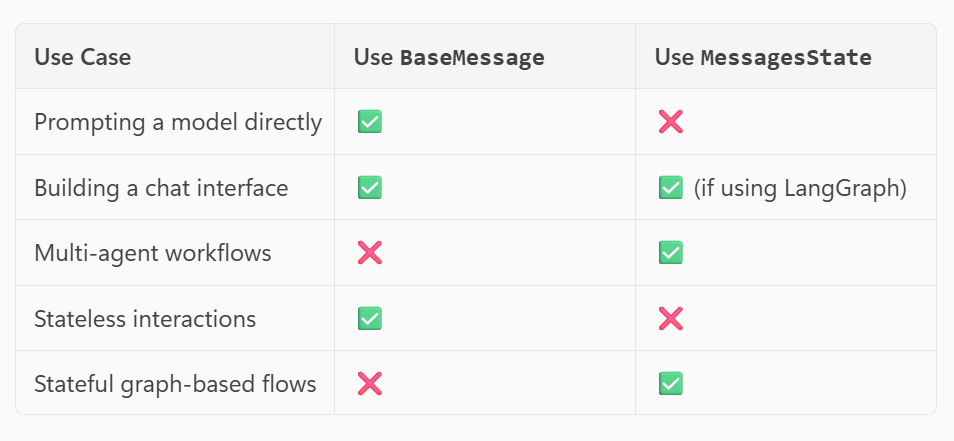